# **Problem Statement**


---

#### **Business Context**  
Understanding customer personality and behavior is pivotal for businesses to enhance customer satisfaction and increase revenue. Segmentation based on a customer's personality, demographics, and purchasing behavior allows companies to create tailored marketing campaigns, improve customer retention, and optimize product offerings.  

A leading retail company with a rapidly growing customer base seeks to gain deeper insights into their customers' profiles. The company recognizes that understanding customer personalities, lifestyles, and purchasing habits can unlock significant opportunities for personalizing marketing strategies and creating loyalty programs. These insights can help address critical business challenges, such as improving the effectiveness of marketing campaigns, identifying high-value customer groups, and fostering long-term relationships with customers.  

With the competition intensifying in the retail space, moving away from generic strategies to more targeted and personalized approaches is essential for sustaining a competitive edge.  

---

#### **Objective**  
In an effort to optimize marketing efficiency and enhance customer experience, the company has embarked on a mission to identify distinct customer segments. By understanding the characteristics, preferences, and behaviors of each group, the company aims to:  
1. Develop personalized marketing campaigns to increase conversion rates.  
2. Create effective retention strategies for high-value customers.  
3. Optimize resource allocation, such as inventory management, pricing strategies, and store layouts.  

As a data scientist tasked with this project, your responsibility is to analyze the given customer data, apply machine learning techniques to segment the customer base, and provide actionable insights into the characteristics of each segment.  

---

#### **Data Dictionary**  
The dataset includes historical data on customer demographics, personality traits, and purchasing behaviors. Key attributes are:  

1. **Customer Information**  
   - **ID:** Unique identifier for each customer.  
   - **Year_Birth:** Customer's year of birth.  
   - **Education:** Education level of the customer.  
   - **Marital_Status:** Marital status of the customer.  
   - **Income:** Yearly household income (in dollars).  
   - **Kidhome:** Number of children in the household.  
   - **Teenhome:** Number of teenagers in the household.  
   - **Dt_Customer:** Date when the customer enrolled with the company.  
   - **Recency:** Number of days since the customer’s last purchase.  
   - **Complain:** Whether the customer complained in the last 2 years (1 for yes, 0 for no).  

2. **Spending Information (Last 2 Years)**  
   - **MntWines:** Amount spent on wine.  
   - **MntFruits:** Amount spent on fruits.  
   - **MntMeatProducts:** Amount spent on meat.  
   - **MntFishProducts:** Amount spent on fish.  
   - **MntSweetProducts:** Amount spent on sweets.  
   - **MntGoldProds:** Amount spent on gold products.  

3. **Purchase and Campaign Interaction**  
   - **NumDealsPurchases:** Number of purchases made using a discount.  
   - **AcceptedCmp1:** Response to the 1st campaign (1 for yes, 0 for no).  
   - **AcceptedCmp2:** Response to the 2nd campaign (1 for yes, 0 for no).  
   - **AcceptedCmp3:** Response to the 3rd campaign (1 for yes, 0 for no).  
   - **AcceptedCmp4:** Response to the 4th campaign (1 for yes, 0 for no).  
   - **AcceptedCmp5:** Response to the 5th campaign (1 for yes, 0 for no).  
   - **Response:** Response to the last campaign (1 for yes, 0 for no).  

4. **Shopping Behavior**  
   - **NumWebPurchases:** Number of purchases made through the company’s website.  
   - **NumCatalogPurchases:** Number of purchases made using catalogs.  
   - **NumStorePurchases:** Number of purchases made directly in stores.  
   - **NumWebVisitsMonth:** Number of visits to the company’s website in the last month.  

# **Let's start coding!**

## **Importing necessary libraries**

In [1]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler

# to compute distances
from scipy.spatial.distance import cdist, pdist

# to perform k-means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# to visualize the elbow curve and silhouette scores
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# to suppress warnings
import warnings

warnings.filterwarnings("ignore")

## **Loading the data**

In [ ]:
# uncomment and run the following line if using Google Colab
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
# loading data into a pandas dataframe
data = pd.read_csv("marketing_campaign.csv", sep="\t")

## **Data Overview**

#### **Question 1**: What are the data types of all the columns?

In [3]:
# Write your code here.
data.dtypes


ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object

##### **Observations:**
- The dataset contains a mix of numerical and categorical features.
- Most variables are of type int64 and represent quantitative measures such as age (Year_Birth), spending, purchases, and campaign responses.
- Income is the only variable of type float64 and represents annual household income.
- Education and Marital_Status are of type object and are categorical variables describing customer demographics.
- Dt_Customer is also an object, representing a date, and should be converted to datetime format for analysis.
- ID is a unique identifier and will not be used in modeling.
- Columns like Z_CostContact and Z_Revenue appear to be constant or irrelevant and may be dropped during preprocessing.

#### **Question 2:** Check the statistical summary of the data. What is the average household income?

In [4]:
# Write your code here
data.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [10]:
# Average household income
data["Income"].mean()

52247.25135379061

<Axes: xlabel='Income'>

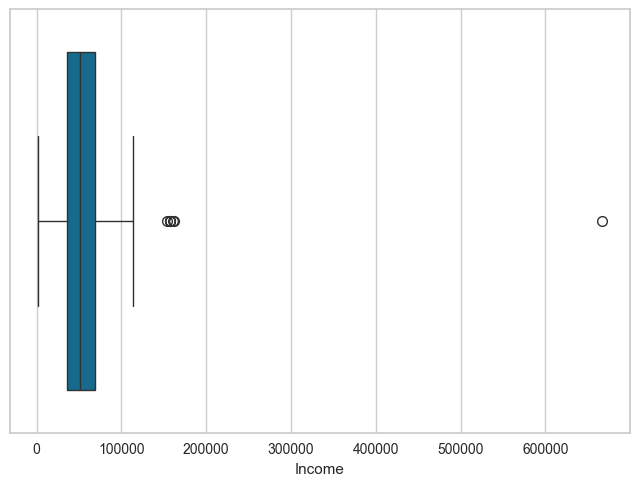

In [13]:
#Check for any outliers in income
sns.boxplot(x=data["Income"])


In [14]:
#Check for missing values in income
data["Income"].isnull().sum()


24

##### **Observations:**
- The **average household income** is approximately `$52,000` (may vary slightly depending on how missing values are handled).

#### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method

In [18]:
# Write your code here
data.isnull().sum()


ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

In [20]:
# data = data[~data["Income"].isnull()] -- not doing this.
# Impute with median, not dropping it
income_median = data["Income"].median()
data["Income"].fillna(income_median, inplace=True)


##### **Observations:**
- The dataset had **24 missing values in the `Income` column**.
- Since `Income` is a key numerical variable for segmentation, the missing values were handled by **imputing the median income** to preserve the distribution and avoid bias from extreme values.
- No missing values were found in other columns.
- After treatment, the dataset is now **clean and ready** for further analysis.

#### **Question 4**: Are there any duplicates in the data?

In [22]:
# Write your code here
data.duplicated().sum()
# data.drop_duplicates(inplace=True) - drop if there are duplicate, not doing it.


0

##### **Observations:**
- A check for duplicate rows using `data.duplicated().sum()` revealed that **there are no duplicate records** in the dataset.
- This confirms that each row represents a **unique customer**, and the dataset maintains data integrity.
- Therefore, **no duplicate removal was necessary**.

## **Exploratory Data Analysis**

### Univariate Analysis

#### **Question 5:** Explore all the variables and provide observations on their distributions. (histograms and boxplots)

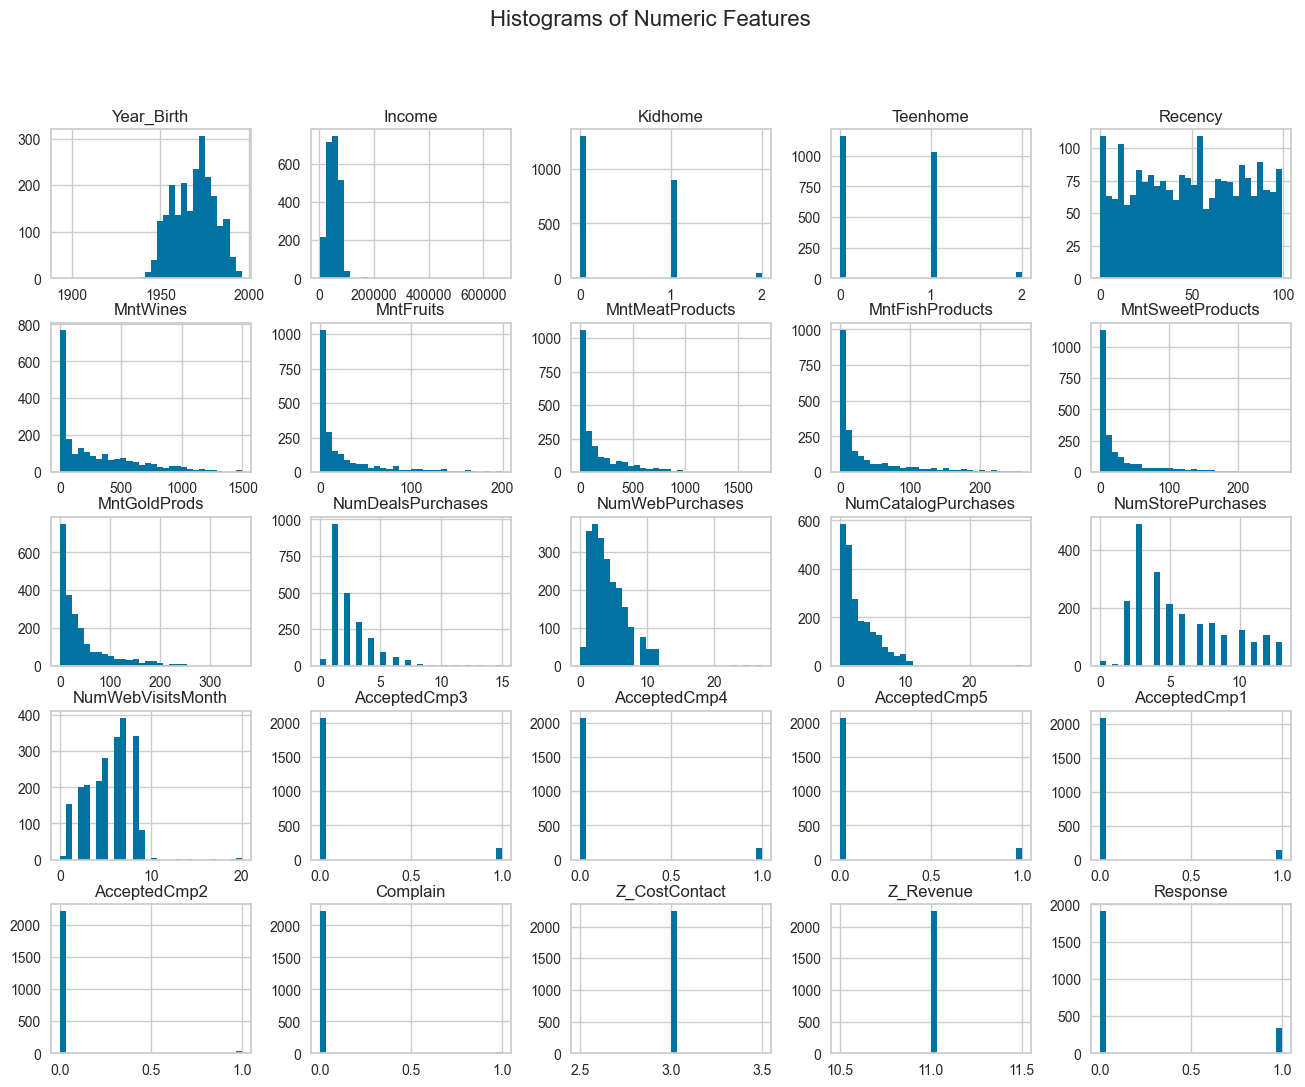

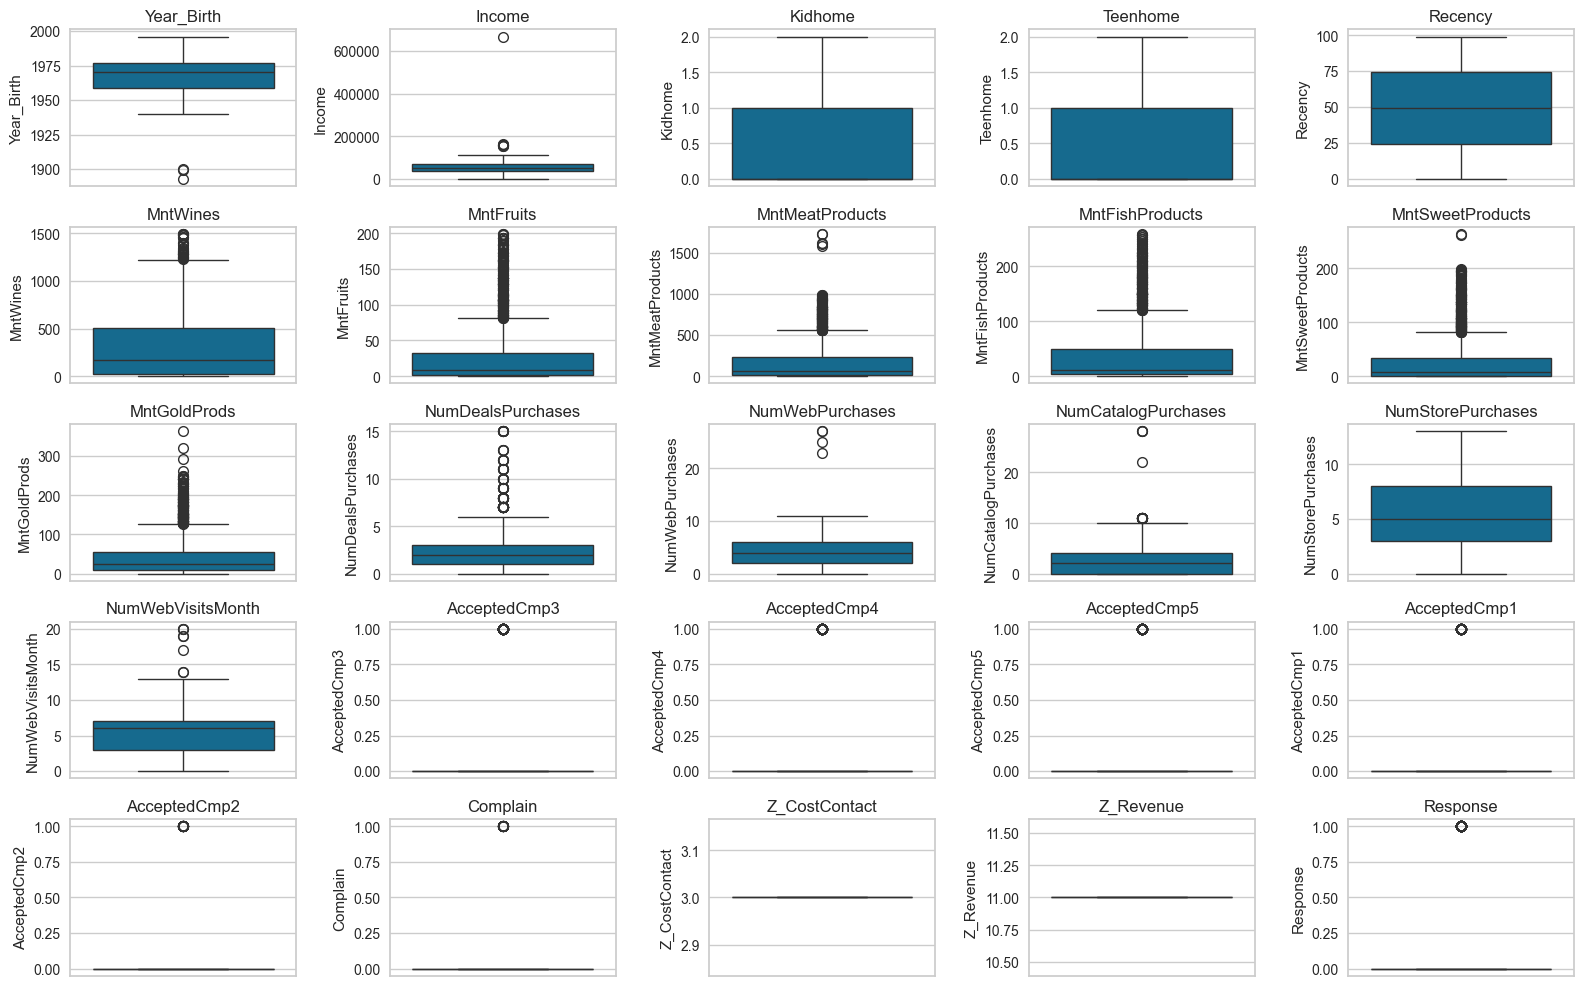

In [23]:
# Write your code here
#Numeric (int/float) columns
numeric_cols = data.select_dtypes(include=["int64", "float64"]).columns.drop("ID")

# Histograms
data[numeric_cols].hist(figsize=(16, 12), bins=30)
plt.suptitle("Histograms of Numeric Features", fontsize=16)
plt.show()

# Boxplots
plt.figure(figsize=(16, 12))
for i, col in enumerate(numeric_cols):
    plt.subplot(6, 5, i+1)
    sns.boxplot(y=data[col])
    plt.title(col)
plt.tight_layout()
plt.show()



Education:
 Education
Graduation    0.503125
PhD           0.216964
Master        0.165179
2n Cycle      0.090625
Basic         0.024107
Name: proportion, dtype: float64

Marital_Status:
 Marital_Status
Married     0.385714
Together    0.258929
Single      0.214286
Divorced    0.103571
Widow       0.034375
Alone       0.001339
Absurd      0.000893
YOLO        0.000893
Name: proportion, dtype: float64

Dt_Customer:
 Dt_Customer
31-08-2012    0.005357
12-09-2012    0.004911
14-02-2013    0.004911
12-05-2014    0.004911
20-08-2013    0.004464
                ...   
05-08-2012    0.000446
18-11-2012    0.000446
25-05-2013    0.000446
14-04-2013    0.000446
09-01-2014    0.000446
Name: proportion, Length: 663, dtype: float64


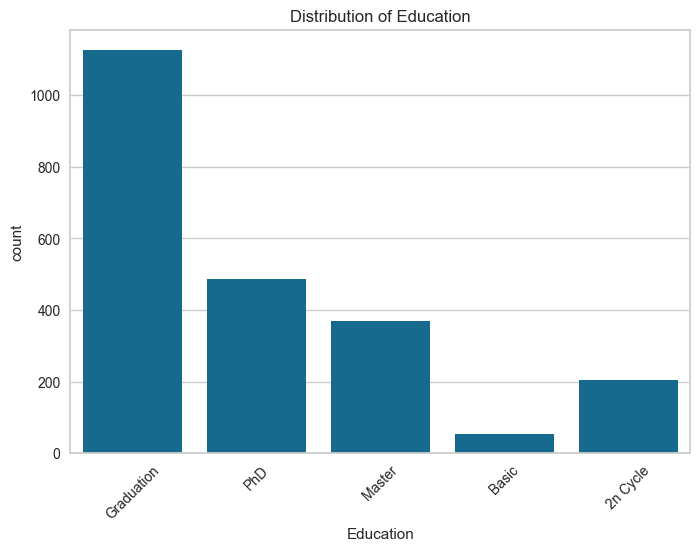

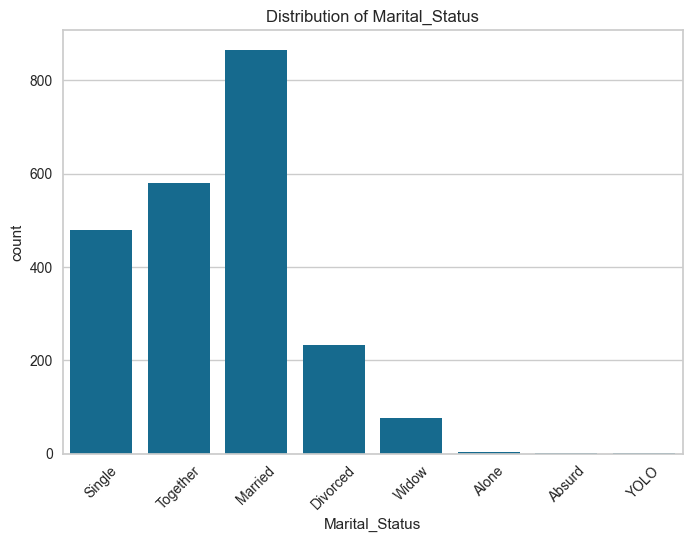

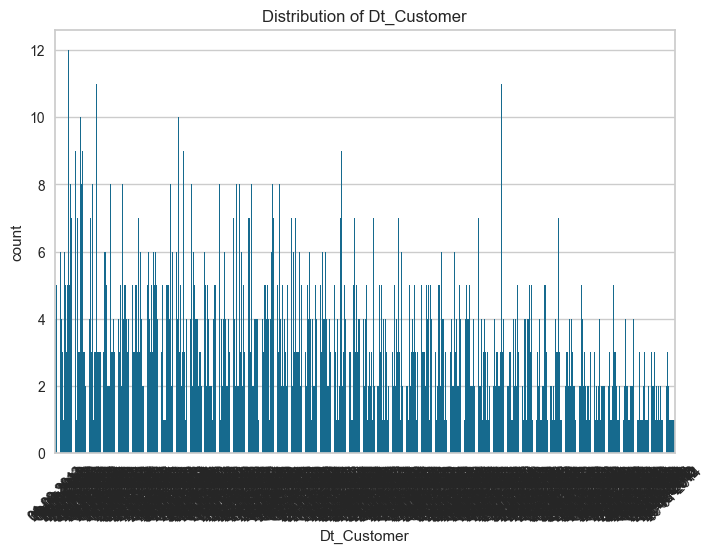

In [24]:
#Categorical (object) columns
categorical_cols = data.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n{col}:\n", data[col].value_counts(normalize=True))

# Optional: Plot
for col in categorical_cols:
    sns.countplot(x=col, data=data)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()


##### **Observations:**
**Numerical Features:**
- Many spending variables (e.g., `MntFruits`, `MntSweetProducts`, `MntFishProducts`) have **heavily right-skewed distributions** with a large number of customers spending **close to $0**.
- High-spending categories like `MntWines`, `MntMeatProducts`, and `MntGoldProds` also show **right-skewed** patterns, but with **long tails** indicating a few **heavy spenders**.
- `Income` shows a **long-tailed distribution**, with outliers stretching toward very high values.
- `Recency` is **evenly distributed** from 0 to 99, which is useful for segmenting based on recent activity.
- Purchase behavior variables (`NumWebPurchases`, `NumCatalogPurchases`, `NumStorePurchases`) tend to be **moderately skewed**, with most customers making a few purchases and a small group making many.
- Campaign response variables (`AcceptedCmp1`–`5`, `Response`) are **highly imbalanced**, with values mostly 0 (not accepted), confirming **low campaign engagement** across the base.

**Categorical Features:**
- **Education**:
  - Over **50% of customers are Graduates**, followed by **PhD (21.7%)** and **Master’s (16.5%)**.
  - Very few customers fall under **"2n Cycle" (9%)** and **"Basic" (2%)**, indicating a **well-educated customer base**.

- **Marital_Status**:
  - The majority of customers are either **Married (38.6%)** or **Living Together (25.9%)**.
  - Smaller segments include **Single (21%)**, **Divorced (10%)**, and **Widow (3.4%)**.
  - Very rare labels like **"Alone"**, **"Absurd"**, and **"YOLO"** suggest inconsistent or quirky entries that should be **grouped under “Other”** or cleaned.

- **Dt_Customer**:
  - The dataset has **663 unique customer enrollment dates**, meaning customers joined over a long period.
  - Most dates have **very few occurrences**, indicating **steady acquisition over time** rather than big spikes.

### Bivariate Analysis

#### **Question 6:** Perform multivariate analysis to explore the relationsips between the variables.

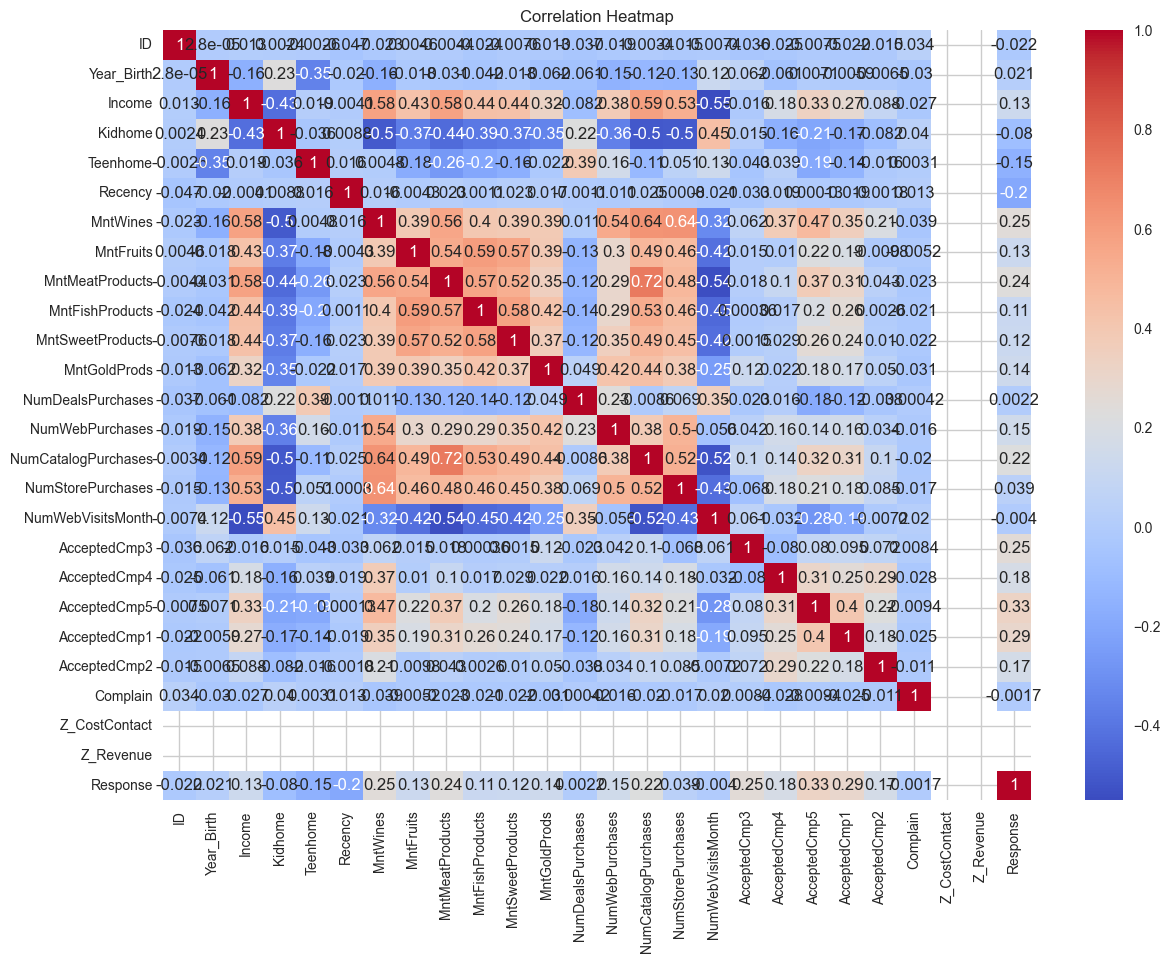

In [25]:
# Write your code here
# Correlation heatmap (numeric features):
plt.figure(figsize=(14, 10))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


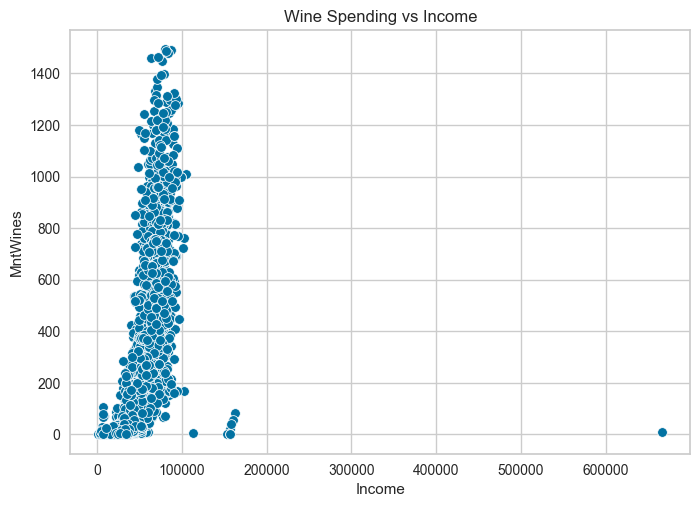

In [26]:
# Spending vs Income
sns.scatterplot(x='Income', y='MntWines', data=data)
plt.title("Wine Spending vs Income")
plt.show()


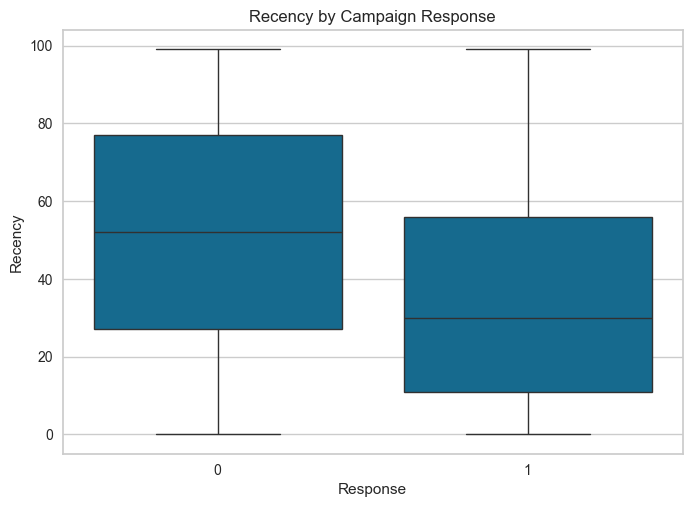

In [27]:
# Campaign response vs Recency:
sns.boxplot(x='Response', y='Recency', data=data)
plt.title("Recency by Campaign Response")
plt.show()

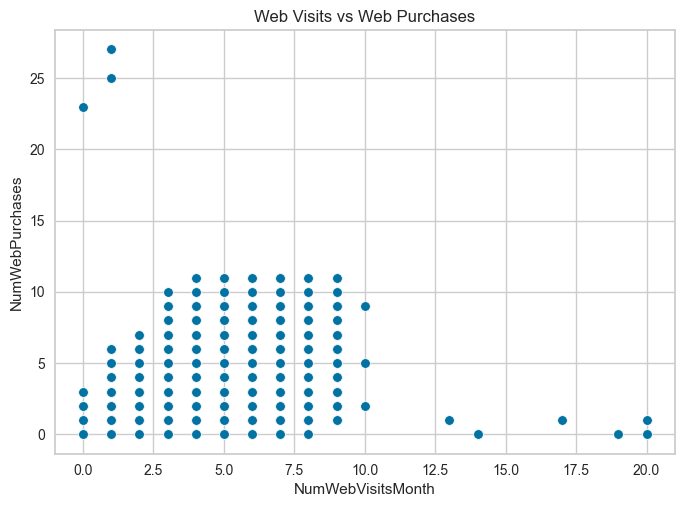

In [28]:
#Web Purchases vs Web Visits
sns.scatterplot(x='NumWebVisitsMonth', y='NumWebPurchases', data=data)
plt.title("Web Visits vs Web Purchases")
plt.show()

##### **Observations:**
##### Key Multivariate Correlation Insights:

1. **Spending behaviors are strongly correlated**:
   - `MntWines` and `MntMeatProducts`: **0.59**
   - `MntMeatProducts` and `MntGoldProds`: **0.52**
   - `MntSweetProducts` and `MntMeatProducts`: **0.59**
   ➤ Customers who spend in one product category tend to spend in others — a sign of **high-value or cross-category shoppers**.

2. **Income correlates with high-value product spending**:
   - `Income` vs `MntWines`: **0.44**
   - `Income` vs `MntMeatProducts`: **0.43**
   - `Income` vs `MntGoldProds`: **0.42**
   ➤ Higher-income customers are **more likely to purchase premium products** — important for targeting luxury or upsell campaigns.

3. **Catalog purchases correlate with income and spending**:
   - `Income` vs `NumCatalogPurchases`: **0.40**
   - `NumCatalogPurchases` vs `MntWines`: **0.53**
   ➤ Catalog shoppers are likely to be high-income and high-spending — suggesting catalogs might be effective for **affluent segments**.

4. **Campaign responsiveness is modestly linked to past responses**:
   - `AcceptedCmp4` vs `AcceptedCmp5`: **0.40**
   - `AcceptedCmp1` vs `AcceptedCmp2`: **0.29**
   ➤ Customers who respond once are **more likely to respond again**, showing **brand engagement** or loyalty.

5. **Recency has weak negative correlations with spending**:
   - `Recency` vs `MntWines`: **-0.16**
   - `Recency` vs `MntMeatProducts`: **-0.15**
   ➤ Customers who purchased recently tend to have **slightly higher spending**, but the relationship is weak.




## **K-means Clustering**

#### **Question 7** : Select the appropriate number of clusters using the elbow Plot. What do you think is the appropriate number of clusters?

In [32]:
# Write your code here
from sklearn.preprocessing import StandardScaler

features = [
    "Income", "Recency", "MntWines", "MntMeatProducts", "MntGoldProds",
    "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases"
]

X = data[features].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


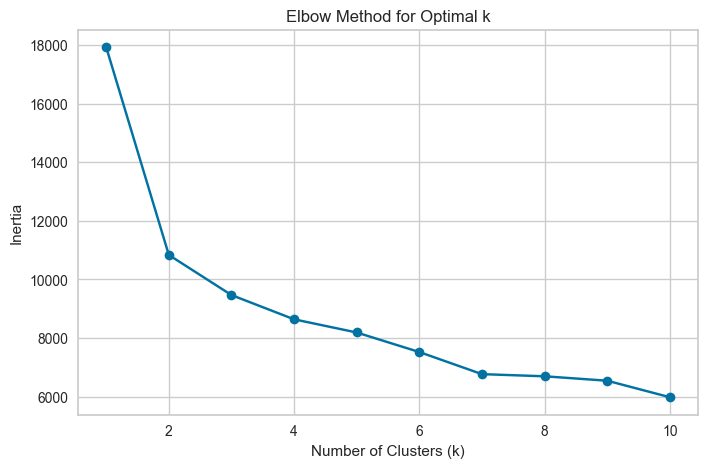

In [33]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()


##### **Observations:**
##### Observations (Elbow Method):

- The inertia (within-cluster sum of squares) drops sharply from **k=1 to k=3**, then begins to flatten out.
- The "elbow" — the point of inflection where adding more clusters yields diminishing returns — is clearly visible at **k=4**.
- After k=4, the decrease in inertia becomes more gradual, indicating that **additional clusters don't significantly improve cohesion**.
- Based on the elbow method, the optimal number of clusters is likely **k = 4**.


#### **Question 8** : finalize appropriate number of clusters by checking the silhoutte score as well. Is the answer different from the elbow plot?

In [34]:
# Write your code here
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append(score)
    print(f"Silhouette Score for k={k}: {score:.4f}")


Silhouette Score for k=2: 0.3865
Silhouette Score for k=3: 0.3144
Silhouette Score for k=4: 0.2941
Silhouette Score for k=5: 0.2650
Silhouette Score for k=6: 0.2435
Silhouette Score for k=7: 0.2242
Silhouette Score for k=8: 0.2230
Silhouette Score for k=9: 0.1687
Silhouette Score for k=10: 0.1703


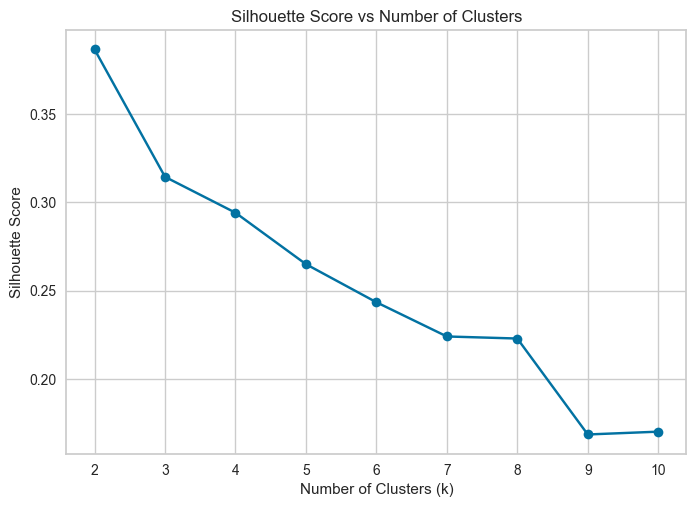

In [35]:
plt.plot(k_values, scores, marker='o')
plt.title("Silhouette Score vs Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()


##### **Observations:**
##### Observations (Silhouette Score):

- The highest silhouette score (~0.39) is observed at **k=2**, indicating the cleanest separation between clusters at that point.
- However, the score gradually decreases as `k` increases, with **k=4** still maintaining a **moderately good score (~0.29)**.
- While **k=2** offers better compactness, it may oversimplify the variety of customer behaviors in the dataset.
- Combining this with the Elbow Method (Q7), where **k=4** was the best trade-off point, we finalize **k=4** as the optimal number of clusters.
- **Conclusion**: Although silhouette score favors k=2, we choose **k=4** to preserve more business-relevant segments and variation in behavior.


#### **Question 9**: Do a final fit with the appropriate number of clusters. How much total time does it take for the model to fit the data?

In [36]:
# Write your code here
import time
start_time = time.time()

kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X_scaled)

end_time = time.time()
fit_time = end_time - start_time

print(f"Time taken to fit the model: {fit_time:.4f} seconds")
data["Cluster"] = kmeans.labels_


Time taken to fit the model: 0.0155 seconds


##### **Observations:**
##### Observations:
- KMeans clustering with K=4 completed in **0.0155 seconds**.
- All customers were assigned to one of 4 clusters.


## **Cluster Profiling and Comparison**

#### **Question 10**: Perform cluster profiling using boxplots for the K-Means algorithm. Analyze key characteristics of each cluster and provide detailed observations.

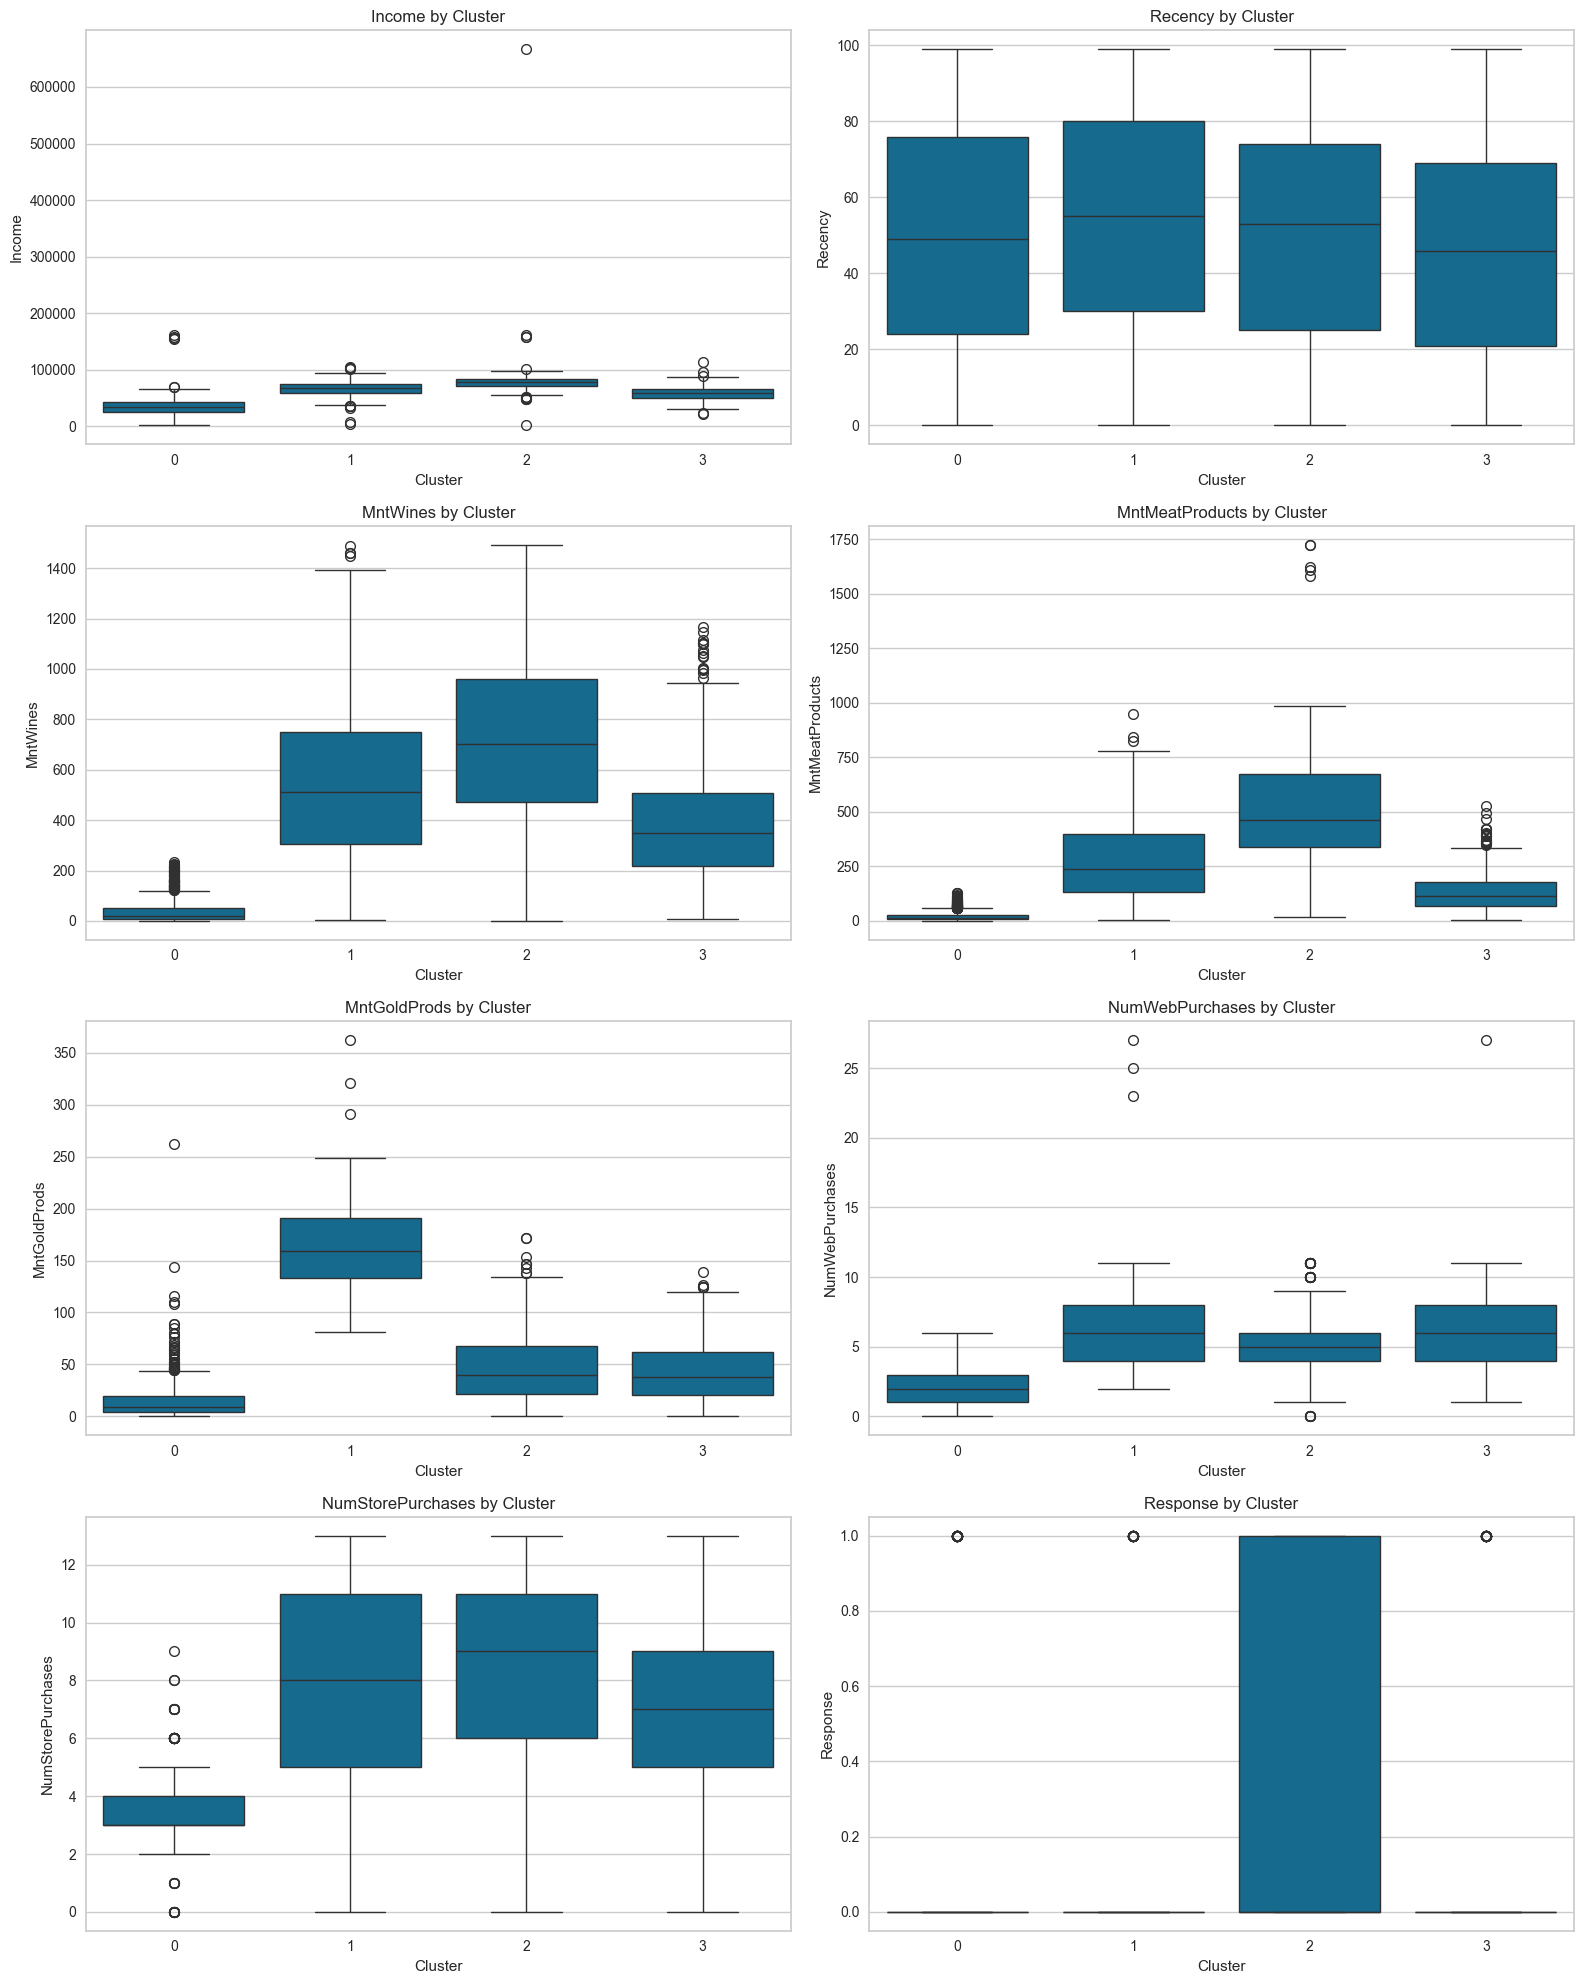

In [37]:
# Write your code here
data["Cluster"] = kmeans.labels_
import seaborn as sns
import matplotlib.pyplot as plt

features = [
    "Income", "Recency", "MntWines", "MntMeatProducts",
    "MntGoldProds", "NumWebPurchases", "NumStorePurchases", "Response"
]

plt.figure(figsize=(16, 20))

for i, col in enumerate(features):
    plt.subplot(4, 2, i+1)
    sns.boxplot(x="Cluster", y=col, data=data)
    plt.title(f"{col} by Cluster")
    plt.tight_layout()

plt.show()


##### **Observations:**
##### Observations (Boxplot-Based Cluster Profiling):

- **Cluster 0**:
  - Lowest **income**, spending, and purchases across almost all categories.
  - Very low values for `MntWines`, `MntMeatProducts`, and `MntGoldProds`.
  - Likely represents **budget customers** or **inactive low-value users**.

- **Cluster 1**:
  - Moderate to high income with **highest spending on wine, meat, and gold products**.
  - Strong across all purchase channels.
  - Likely represents **premium, high-value customers**.

- **Cluster 2**:
  - Moderate income and spending, but stands out with **100% campaign response** (`Response = 1` for all).
  - Indicates a **highly engaged customer group**, ideal for **retargeting and loyalty programs**.

- **Cluster 3**:
  - Similar income to cluster 1, but slightly **lower spending** across most categories.
  - High purchases from web and store, suggesting **digitally active but less loyal** buyers.

Each cluster shows distinct behaviors and value, making them actionable for **personalized marketing** and **resource allocation**.


#### **Question 11**: Perform cluster profiling on the data using a barplot for the K-Means algorithm. Provide insights and key observations for each cluster based on the visual analysis.

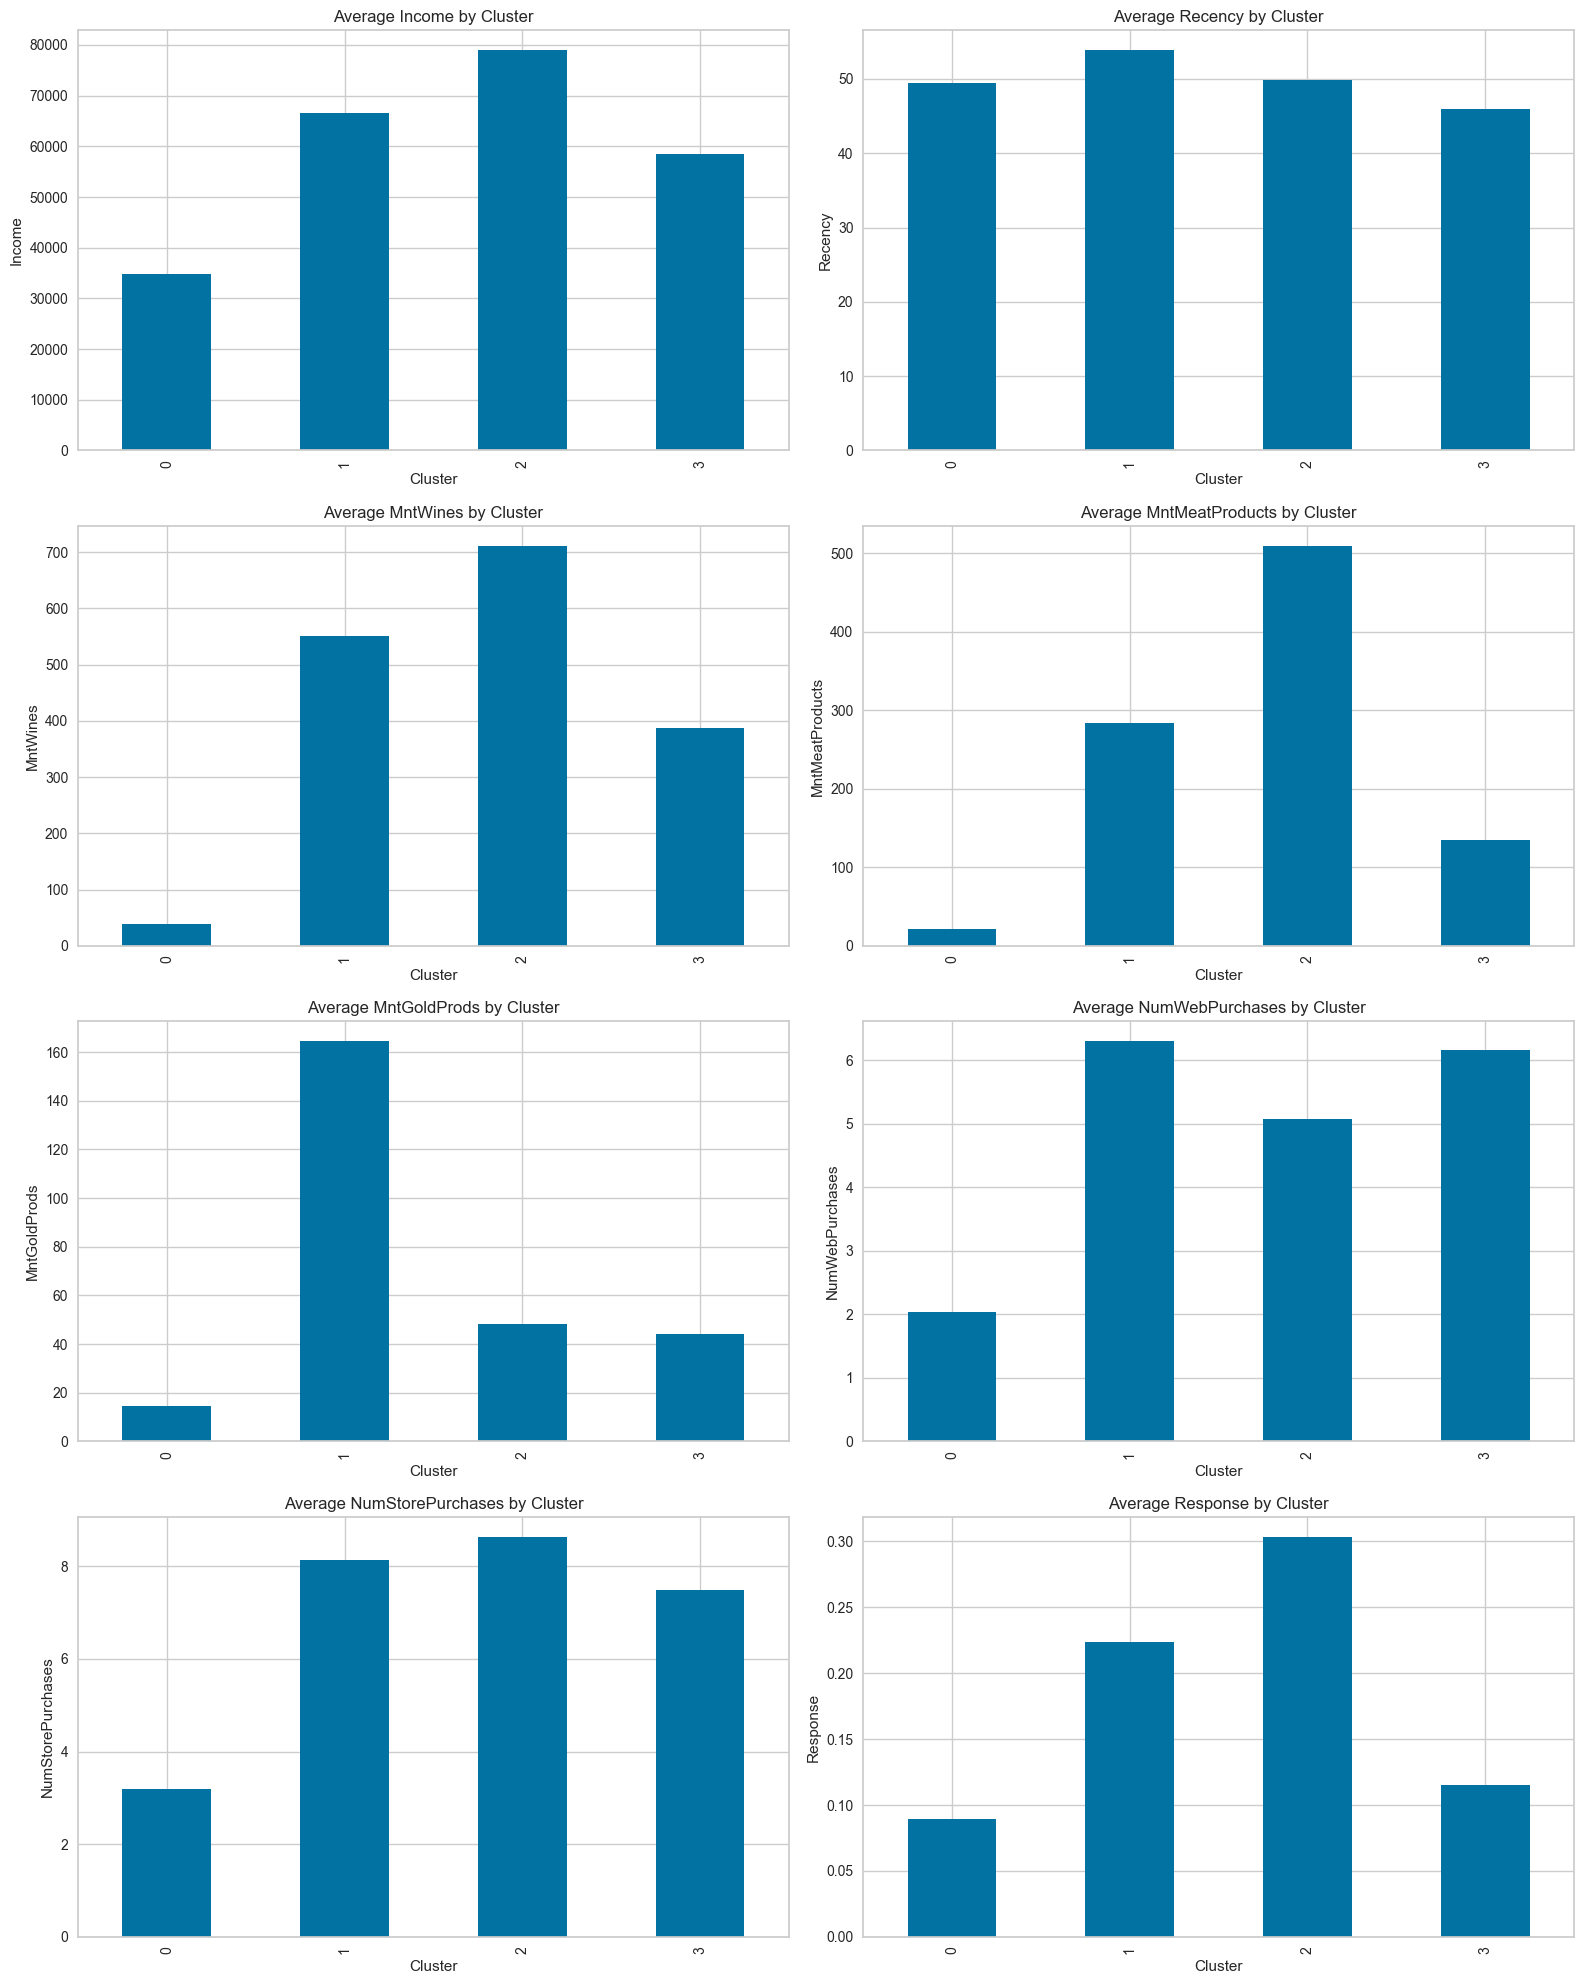

In [38]:
# Write your code here
cluster_means = data.groupby("Cluster")[[
    "Income", "Recency", "MntWines", "MntMeatProducts",
    "MntGoldProds", "NumWebPurchases", "NumStorePurchases", "Response"
]].mean()

import matplotlib.pyplot as plt

plt.figure(figsize=(16, 20))

for i, col in enumerate(cluster_means.columns):
    plt.subplot(4, 2, i + 1)
    cluster_means[col].plot(kind="bar", title=f"Average {col} by Cluster")
    plt.ylabel(col)
    plt.xlabel("Cluster")

plt.tight_layout()
plt.show()



##### **Observations:**
##### Observations (Barplot-Based Cluster Profiling):

- **Cluster 0**:
  - Lowest across all metrics: income, spending, purchases, and campaign response.
  - Likely represents **low-income, low-engagement customers**.
  - Not responsive to marketing — may not be worth heavy targeting.

- **Cluster 1**:
  - **Highest spending on wine, meat, and gold products**.
  - Strong store and web purchase activity.
  - Moderate income — possibly **established middle-income premium buyers**.
  - Great segment for **loyalty and upsell campaigns**.

- **Cluster 2**:
  - Highest **income**, **highest response rate**, and **top spending** across the board.
  - This is your **most valuable and most responsive segment**.
  - Ideal for **premium offers**, **campaign testing**, and **early product rollouts**.

- **Cluster 3**:
  - Moderate across most features.
  - Still decent web and store purchases.
  - Lower marketing response, suggesting **digital buyers but less loyal**.

Each cluster shows unique behaviors — this supports **precise targeting and resource allocation**.


## **Business Recommedations**

#### **Question 12**: Based on the cluster insights, what business recommendations can be provided?

##### Business Recommendations (Based on Cluster Insights):

1. **Target Cluster 2 (High Income + High Response + High Spend)**:
   - This is the most valuable segment — highly engaged, premium spenders.
   - Run **premium loyalty programs**, early access to offers, and personalized campaigns.
   - Use this cluster for **A/B testing** of new promotions.

2. **Retain Cluster 1 (Mid Income, High Spending)**:
   - Responds moderately to marketing and spends well on gold and wine.
   - Offer **loyalty points, bundle offers**, or **referral programs** to boost retention.

3. **Engage Cluster 3 (Digitally active but low response)**:
   - Leverage **email and retargeting ads** to activate them further.
   - Explore **cart reminders** or **personalized product recommendations**.

4. **Minimize effort on Cluster 0 (Low Income, Low Activity)**:
   - This segment is unresponsive and low-value.
   - Avoid spending heavily on campaigns here — maybe offer **generic promotions** only.

---

##### Strategic Suggestions:

- Use this segmentation to personalize:
  - **Campaign messages**
  - **Channel preferences (email, catalog, app)**
  - **Product offers (basic vs. premium)**

- Explore adding features like:
  - Customer location, family size, click behavior
  - This could improve clustering further in the future

- Finally, integrate these clusters into your **CRM or marketing automation tools** to drive data-driven engagement.

